### Phase 1: Physics engines

In [1]:
import sympy as sp

t,k = sp.symbols('t k')
omega=sp.Function('omega')(t)

spin_eq=sp.Eq(omega.diff(t),-k*omega)

spin_solution=sp.dsolve(spin_eq)
print("The theoretical physics equation for our relation is:")
print(spin_solution)

import numpy as np
np.random.seed(42)


The theoretical physics equation for our relation is:
Eq(omega(t), C1*exp(-k*t))


### Phase 2: Data Engineering

In [4]:
import numpy as np

#Setup seed
np.random.seed(42)

#Define the scale of our simulation
num_launches=1000
time_steps=100
t=np.linspace(0,15,time_steps)

#Randomize initial conditions
omega_0=np.random.uniform(3000,7000,num_launches).reshape(-1,1)
k=np.random.uniform(0.1,0.8,num_launches).reshape(-1,1)

#Use the mathematical equation obtained in phase 1
pure_spin=omega_0*np.exp(-k*t)

#Introduce sensor noise
noise=np.random.normal(loc=0,scale=40,size=pure_spin.shape)
noise_spin=pure_spin+noise

#RPM can't drop below absolute zero
final_spin_data=np.maximum(noise_spin,0)

print(f"Generated dataset shape: {final_spin_data.shape}")
print(f"Launch 1 starts at {final_spin_data[0][0]:.0f} RPM and ends at {final_spin_data[0][-1]:.0f} RPM.")


Generated dataset shape: (1000, 100)
Launch 1 starts at 4463 RPM and ends at 157 RPM.


### Phase 3: Data Visualization

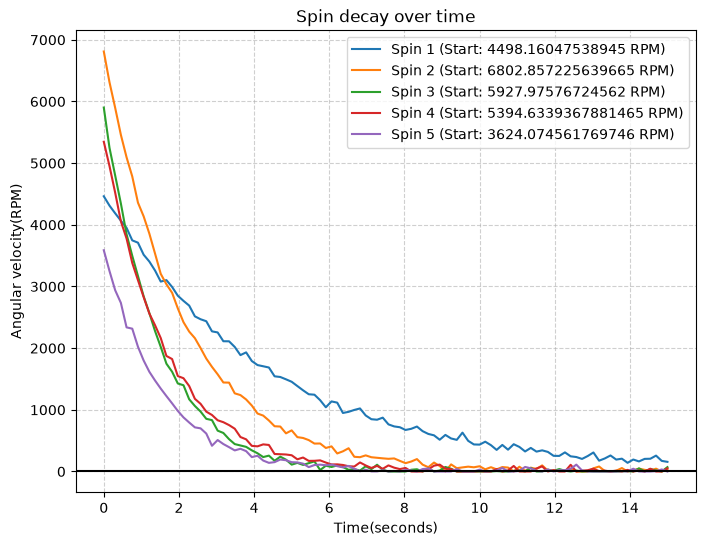

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

#simulate the first 5 spins to keep the graph readable
for i in range(5):
    plt.plot(t,final_spin_data[i],label=f'Spin {i+1} (Start: {omega_0[i][0]} RPM)')

plt.title("Spin decay over time")
plt.xlabel("Time(seconds)")
plt.ylabel("Angular velocity(RPM)")
plt.axhline(0,color='black',linewidth=1.5)
plt.grid(True,linestyle='--',alpha=0.6)
plt.legend()
plt.show()
